## 사용 데이터
- 2024.08 ~ 2025.10 서울특별시 월세 실거래가 데이터
- 한국은행 기준금리(환산보증금을 계산하기 위함)
- 시장 및 대출금리

    | 컬럼명              | 한 줄 요약                                              |
    | ------------------- | -------------------------------------------------------- |
    | 소비자물가          | 물가가 얼마나 올랐는지 보여주는 지표. 물가↑ → 월세 인상 압력↑ |
    | KORIBOR             | 은행끼리 돈을 빌릴 때 적용하는 기준 금리. 시장 기준금리 역할 |
    | 기업대출            | 기업이 대출받을 때 적용되는 금리. 경기 흐름을 반영하는 간접 지표 |
    | 전세자금대출        | 세입자가 전세 계약 시 부담하는 대출 금리. 전세 부담↑ → 월세 수요↑ |
    | CD                  | 은행 예금·대출의 기준이 되는 금리. 전세보다 월세 선호를 높이는 요인 |
    | 무담보콜금리        | 은행 간 초단기 자금 거래 금리. 금융시장 단기 유동성 지표 |
    | 변동형주택담보대출  | 주택담보대출의 변동금리. 집주인 이자 부담↑ → 월세·보증금 인상 압력 |



## 라이브러리 임포트 및 데이터 로드

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error,
)

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor


sns.set(style="whitegrid", font="Malgun Gothic")  # 윈도우 한글 폰트
plt.rcParams["axes.unicode_minus"] = False        # 마이너스 깨짐 방지

# 데이터 경로
BASE_DIR = Path("C:/dev/SKN18-FINAL-1TEAM/data/actual_transaction_price")

train_path = BASE_DIR / "월세_train(24.08~25.08).csv"
test_path  = BASE_DIR / "월세_test(25.09~25.10).csv"

train = pd.read_csv(train_path, encoding="utf-8-sig")
test  = pd.read_csv(test_path,  encoding="utf-8-sig")

print("train:", train.shape)
print("test :", test.shape)
train.head()

train: (423570, 17)
test : (52236, 17)


,자치구명,법정동명,층,연월,임대면적,보증금(만원),임대료(만원),건축년도,건물용도,소비자물가,무담보콜금리,KORIBOR,CD,기업대출,전세자금대출,변동형주택담보대출,기준금리
0,마포구,노고산동,5.0,2024-12,31.12,8000,50,1998.0,오피스텔,1.9,3.055,3.31,3.35,4.62,4.34,4.32,3.00
1,종로구,명륜3가,2.0,2024-09,20.96,500,76,1996.0,연립다세대,1.6,3.529,3.49,3.52,4.77,4.05,4.08,3.50
2,강북구,수유동,3.0,2024-09,20.00,1000,70,2023.0,연립다세대,1.6,3.529,3.49,3.52,4.77,4.05,4.08,3.50
3,용산구,용산동2가,2.0,2024-11,21.84,500,60,2020.0,연립다세대,1.5,3.245,3.40,3.42,4.76,4.43,4.25,3.25
4,종로구,명륜3가,4.0,2024-08,47.58,500,40,1997.0,연립다세대,2.0,3.531,3.45,3.50,4.67,3.82,4.04,3.50


## 환산보증금_평당가 타깃 생성
> 환산보증금 = 보증금 + (월세*12) / ((기준금리+2)/100)


In [19]:
TARGET = "환산보증금_평당가"
# TARGET_LOG = "log_" + TARGET 

df_train = train.copy()
df_test  = test.copy()

for df in [df_train, df_test]:
    # 안전한 최소 이자율 (0 이하 방지)
    df["적용이자율"] = (df["기준금리"] + 2.0) / 100.0
    df.loc[df["적용이자율"] <= 0, "적용이자율"] = np.nan

    # 환산보증금: 보증금 + 월세를 전세로 환산
    df["환산보증금(만원)"] = df["보증금(만원)"] + (df["임대료(만원)"] * 12) / df["적용이자율"]

    # 평수 (임대면적이 ㎡라면 3.3으로 나눔)
    df["전용평수"] = df["임대면적"] / 3.3

    # 평당 환산보증금 (타깃)
    df[TARGET] = df["환산보증금(만원)"] / df["전용평수"]

    # df[TARGET_LOG] = np.log1p(df[TARGET])

df_train[[ "보증금(만원)", "임대료(만원)", "기준금리", "적용이자율", "환산보증금(만원)", "전용평수", TARGET]].head()

,보증금(만원),임대료(만원),기준금리,적용이자율,환산보증금(만원),전용평수,환산보증금_평당가
0,8000,50,3.00,0.0500,20000.000000,9.430303,2120.822622
1,500,76,3.50,0.0550,17081.818182,6.351515,2689.408397
2,1000,70,3.50,0.0550,16272.727273,6.060606,2685.000000
3,500,60,3.25,0.0525,14214.285714,6.618182,2147.762951
4,500,40,3.50,0.0550,9227.272727,14.418182,639.974779


In [20]:
print("=== train.info ===")
df_train.info()

=== train.info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 423570 entries, 0 to 423569
Data columns (total 21 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   자치구명       423570 non-null  object 
 1   법정동명       423570 non-null  object 
 2   층          423570 non-null  float64
 3   연월         423570 non-null  object 
 4   임대면적       423570 non-null  float64
 5   보증금(만원)    423570 non-null  int64  
 6   임대료(만원)    423570 non-null  int64  
 7   건축년도       423570 non-null  float64
 8   건물용도       423570 non-null  object 
 9   소비자물가      423570 non-null  float64
 10  무담보콜금리     423570 non-null  float64
 11  KORIBOR    423570 non-null  float64
 12  CD         423570 non-null  float64
 13  기업대출       423570 non-null  float64
 14  전세자금대출     423570 non-null  float64
 15  변동형주택담보대출  423570 non-null  float64
 16  기준금리       423570 non-null  float64
 17  적용이자율      423570 non-null  float64
 18  환산보증금(만원)  423570 non-null  float64
 19  전용평수

In [21]:
print("\n=== 결측비율 (train) ===")
df_train.isnull().sum().sort_values(ascending=False).head(20)


=== 결측비율 (train) ===


자치구명         0
법정동명         0
층            0
연월           0
임대면적         0
보증금(만원)      0
임대료(만원)      0
건축년도         0
건물용도         0
소비자물가        0
무담보콜금리       0
KORIBOR      0
CD           0
기업대출         0
전세자금대출       0
변동형주택담보대출    0
기준금리         0
적용이자율        0
환산보증금(만원)    0
전용평수         0
dtype: int64

## EDA

In [22]:
# # 타깃 분포
# plt.figure(figsize=(8, 4))
# sns.histplot(df_train[TARGET].dropna(), bins=50, kde=True)
# plt.title("환산보증금_평당가 분포")
# plt.show()

# # 로그 스케일 분포 (꼬리 완화용)
# df_train["log_" + TARGET] = np.log1p(df_train[TARGET])

# plt.figure(figsize=(8, 4))
# sns.histplot(df_train["log_" + TARGET].dropna(), bins=50, kde=True)
# plt.title("log(환산보증금_평당가) 분포")
# plt.show()


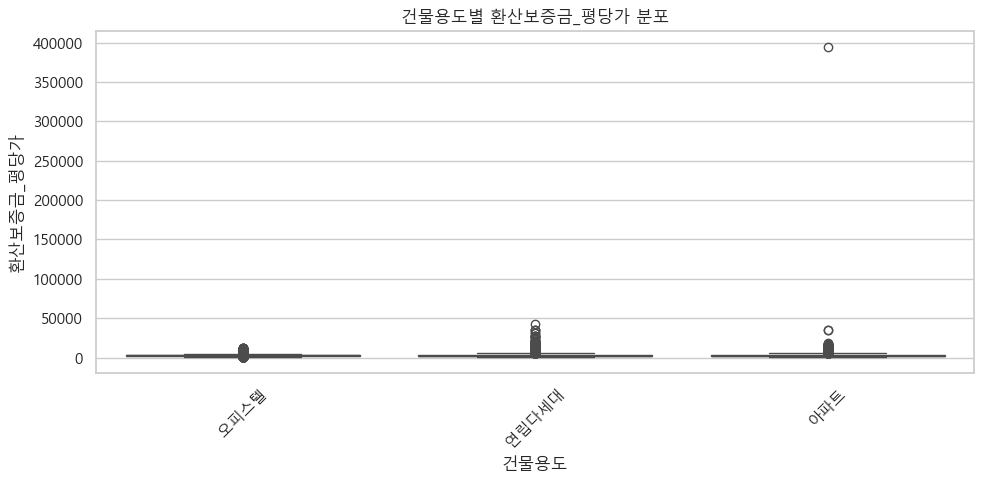

In [23]:
# 건물용도별 평당가
if "건물용도" in df_train.columns:
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=df_train, x="건물용도", y=TARGET)
    plt.xticks(rotation=45)
    plt.title("건물용도별 환산보증금_평당가 분포")
    plt.tight_layout()
    plt.show()

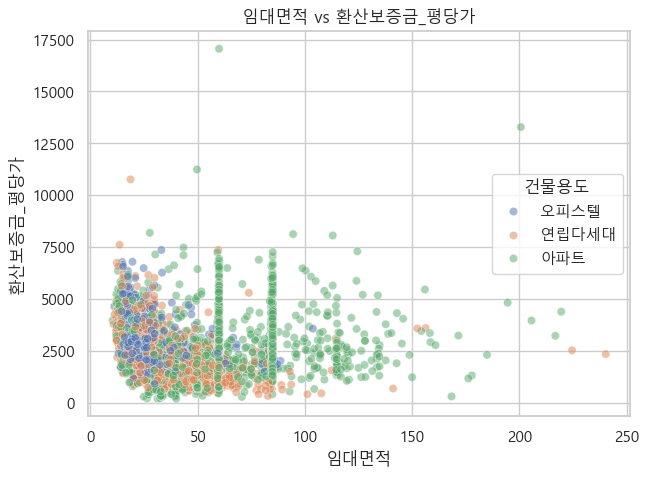

In [24]:
# 임대면적 vs 평당가 (면적이 큰 집일수록 평당가 하락하는지 등)
plt.figure(figsize=(7, 5))
sample = df_train.sample(min(len(df_train), 4000), random_state=42)
sns.scatterplot(data=sample, x="임대면적", y=TARGET, hue="건물용도", alpha=0.5)
plt.title("임대면적 vs 환산보증금_평당가")
plt.show()

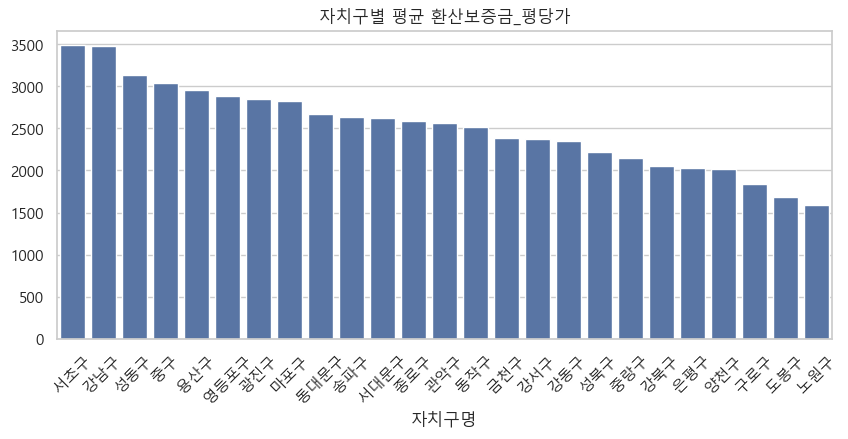

In [25]:
# 자치구별 평균 평당가 (지역 프리미엄)
if {"자치구명", TARGET}.issubset(df_train.columns):
    gu_mean = df_train.groupby("자치구명")[TARGET].mean().sort_values(ascending=False)
    plt.figure(figsize=(10, 4))
    sns.barplot(x=gu_mean.index.astype(str), y=gu_mean.values)
    plt.xticks(rotation=45)
    plt.title("자치구별 평균 환산보증금_평당가")
    plt.show()

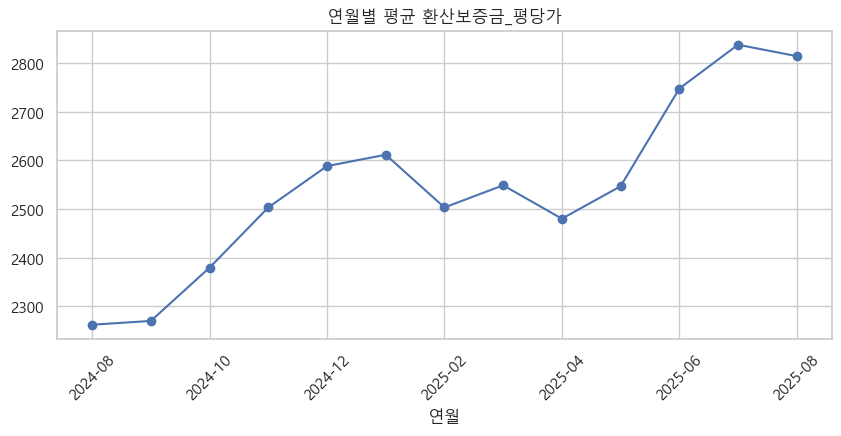

In [26]:
# 시간(연월)에 따른 시세 흐름
if {"연월", TARGET}.issubset(df_train.columns):
    month_mean = df_train.groupby("연월")[TARGET].mean()
    plt.figure(figsize=(10, 4))
    month_mean.plot(marker="o")
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.title("연월별 평균 환산보증금_평당가")
    plt.show()

In [27]:
num_cols = df_train.select_dtypes(include=[np.number]).columns.tolist()
corr = df_train[num_cols].corr()

# 타깃과의 상관계수
target_corr = corr[TARGET].sort_values(ascending=False)
target_corr

환산보증금_평당가    1.000000
환산보증금(만원)    0.503949
임대료(만원)      0.480194
건축년도         0.352420
보증금(만원)      0.269683
층            0.221848
소비자물가        0.033325
변동형주택담보대출   -0.025162
전세자금대출      -0.046123
기업대출        -0.083397
임대면적        -0.084092
전용평수        -0.084092
CD          -0.087455
KORIBOR     -0.087503
무담보콜금리      -0.096964
적용이자율       -0.097865
기준금리        -0.097865
Name: 환산보증금_평당가, dtype: float64

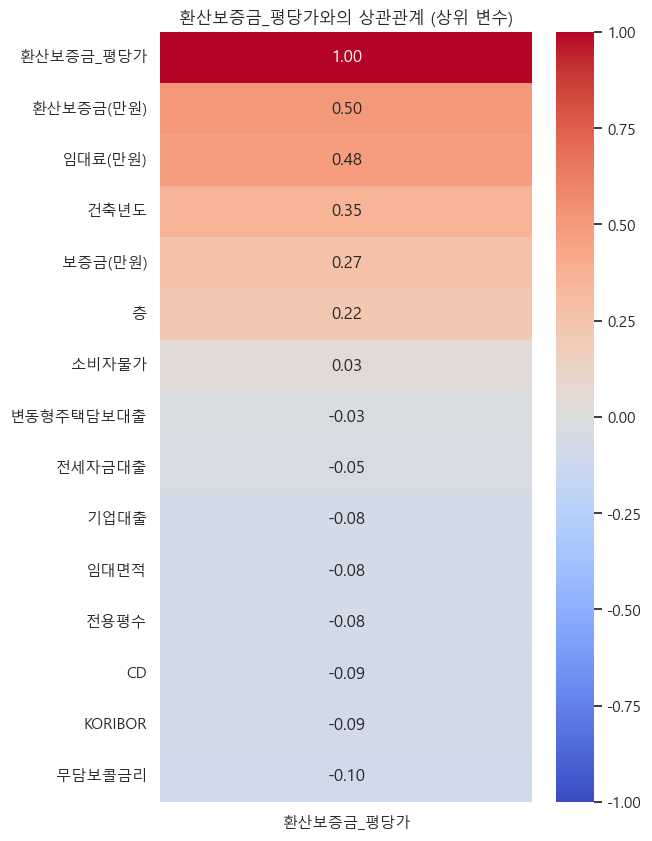

In [28]:
# 타깃과 상관 높은 상위 변수 히트맵
top_n = 15
top_features = target_corr.index[:top_n]

plt.figure(figsize=(6, 10))
sns.heatmap(
    corr.loc[top_features, [TARGET]],
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)
plt.title("환산보증금_평당가와의 상관관계 (상위 변수)")
plt.show()

In [1]:
# 연속형 분포 확인
df[["층", "건축년도", "전용평수", "임대면적", "소비자물가"]].describe()

df["층"].hist(bins=30); plt.title("층 분포"); plt.show()
df["전용평수"].hist(bins=30); plt.title("전용평수 분포"); plt.show()
df['건축년도'].hist(bins=30); plt.title("건축년도 분포"); plt.show()
df['임대면적'].hist(bins=30); plt.title("임대면적 분포"); plt.show()
df['소비자물가'].hist(bins=30); plt.title("소비자물가 분포"); plt.show()

NameError: name 'df' is not defined

In [2]:
# 1) 모델링에 쓸 행만 남기기
df_train_ml = df_train.dropna(subset=[TARGET_LOG]).copy()
df_train_ml = df_train_ml.sort_values("연월").reset_index(drop=True)
df_test_ml  = df_test.copy()

NameError: name 'df_train' is not defined

In [ ]:
def eda_numeric_bins(df, col, target=TARGET_LOG, q=4):
    print(f"\n===== [{col}] 기본 통계 =====")
    print(df[col].describe())
    
    print(f"\n===== [{col}] 히스토그램용 구간별 개수 (q={q}) =====")
    df[f"{col}_qcut"], bins = pd.qcut(df[col], q=q, retbins=True, duplicates="drop")
    print(df[f"{col}_qcut"].value_counts().sort_index())
    
    print(f"\n===== [{col}] 구간별 타겟 평균 =====")
    print(
        df.groupby(f"{col}_qcut")[target]
          .agg(["count", "mean", "median"])
          .sort_index()
    )
    
    # 필요 없으면 나중에 드롭
    df.drop(columns=[f"{col}_qcut"], inplace=True)
    return bins

bins_floor   = eda_numeric_bins(df_train_ml, "층")
bins_area    = eda_numeric_bins(df_train_ml, "임대면적")
bins_age     = eda_numeric_bins(df_train_ml, "건물연식")

In [ ]:
for df_ in [df_train_ml, df_test_ml, df_train, df_test]:
    if "계약연도" not in df_.columns:
        df_["계약연도"] = pd.to_datetime(df_["연월"]).dt.year
        df_["계약월"] = pd.to_datetime(df_["연월"]).dt.month

    if "건물연식" not in df_.columns:
        df_["건물연식"] = df_["계약연도"] - df_["건축년도"]

In [14]:
# 복합 카테고리 생성
df_train_ml["자치구_건물용도"] = df_train_ml["자치구명"] + "_" + df_train_ml["건물용도"]
df_test_ml["자치구_건물용도"] = df_test_ml["자치구명"] + "_" + df_test_ml["건물용도"]

df_train_ml["자치구_건물용도"].value_counts()
# type(df_train_ml["자치구_건물용도"].dtype)

자치구_건물용도
관악구_단독다가구    25997
송파구_연립다세대    19590
강서구_오피스텔     17561
광진구_단독다가구    17533
강남구_아파트      17125
             ...  
강북구_오피스텔      1297
용산구_오피스텔      1239
동작구_오피스텔      1051
성북구_오피스텔      1013
노원구_오피스텔       630
Name: count, Length: 100, dtype: int64

In [ ]:
# 자치구별 샘플 수 (인기 지역 지표)
gu_count = df_train_ml.groupby("자치구명").size().to_dict()
df_train_ml["자치구_거래량"] = df_train_ml["자치구명"].map(gu_count)
df_test_ml["자치구_거래량"] = df_test_ml["자치구명"].map(gu_count)

df_train_ml["자치구_거래량"].value_counts()

numpy.dtypes.Int64DType

In [ ]:
# 법정동별 샘플 수
dong_count = df_train_ml.groupby("법정동명").size().to_dict()
df_train_ml["법정동_거래량"] = df_train_ml["법정동명"].map(dong_count)
df_test_ml["법정동_거래량"] = df_test_ml["법정동명"].map(dong_count)

df_train_ml["법정동_거래량"].value_counts()

법정동_거래량
21987    21987
20537    20537
14712    14712
10748    10748
9364      9364
         ...  
7            7
3            6
6            6
2            6
1            2
Name: count, Length: 350, dtype: int64

In [25]:
# 자치구별 평균 건물연식 (오래된 동네 vs 신도시)
gu_age = df_train.groupby("자치구명")["건물연식"].mean().to_dict()
df_train_ml["자치구_평균건물연식"] = df_train_ml["자치구명"].map(gu_age)
df_test_ml["자치구_평균건물연식"] = df_test_ml["자치구명"].map(gu_age)

df_train_ml["자치구_평균건물연식"].value_counts()

자치구_평균건물연식
17.298129    49009
17.478879    44055
14.370276    42733
19.764662    37325
18.321444    33082
15.332218    32590
21.354916    31754
15.808151    31160
17.484371    27289
15.769845    27034
18.438781    26879
18.689773    23428
17.129751    22443
20.766213    21772
18.991758    19656
26.153033    19584
19.811480    19059
21.395770    18627
14.166638    17523
22.294684    16930
23.179072    13045
20.394463    12858
24.193647    10767
21.923969    10351
17.252579     9597
Name: count, dtype: int64

In [22]:
# 층: 저층 / 중층 / 고층
floor_bins = [-np.inf, 5, 15, np.inf]
floor_labels = ["저층", "중층", "고층"]
df_train_ml["층_카테고리"] = pd.cut(df_train_ml["층"], bins=floor_bins, labels=floor_labels)
df_test_ml["층_카테고리"]  = pd.cut(df_test_ml["층"],  bins=floor_bins, labels=floor_labels)

df_train_ml["층_카테고리"].value_counts()

층_카테고리
저층    402272
중층    177123
고층     39155
Name: count, dtype: int64

In [ ]:
TARGET = "환산보증금_평당가"
TARGET_LOG = "log_" + TARGET

df_train_ml.groupby("건물연식_구간")[TARGET_LOG].agg(["count","mean","median"])

In [ ]:
# 건물연식: 신축 / 중간 / 노후 (예시: 0~5, 5~20, 20년 이상)
age_bins = [-np.inf, 5, 20, np.inf]
age_labels = ["신축", "준신축", "구축"]
df_train_ml["건물연식_구간"] = pd.cut(df_train_ml["건물연식"], bins=age_bins, labels=age_labels)
df_test_ml["건물연식_구간"]  = pd.cut(df_test_ml["건물연식"],  bins=age_bins, labels=age_labels)
df_train_ml["건물연식_구간"].value_counts()

건물연식_구간
구축     267738
준신축    245086
신축     105726
Name: count, dtype: int64

In [24]:
# 임대면적: 분위수 기반 소형 / 중형 / 대형
q1, q2 = df_train_ml["임대면적"].quantile([0.33, 0.66])
area_bins = [-np.inf, q1, q2, np.inf]
area_labels = ["소형", "중형", "대형"]
df_train_ml["임대면적_구간"] = pd.cut(df_train_ml["임대면적"], bins=area_bins, labels=area_labels)
df_test_ml["임대면적_구간"]  = pd.cut(df_test_ml["임대면적"],  bins=area_bins, labels=area_labels)
df_train_ml["임대면적_구간"].value_counts()

임대면적_구간
대형    210288
소형    204137
중형    204125
Name: count, dtype: int64

In [ ]:
# # 지역별 면적당 거래량 (인기 지표)
df_train_ml["자치구_평균면적"] = df_train_ml.groupby("자치구명")["임대면적"].transform("mean")
df_test_gu_area = df_train_ml.groupby("자치구명")["임대면적"].mean().to_dict()
df_test_ml["자치구_평균면적"] = df_test_ml["자치구명"].map(df_test_gu_area)

df_train_ml["자치구_평균면적"].value_counts()

자치구_평균면적
46.403664    49009
31.894242    44055
35.791750    42733
52.807863    37325
39.962481    33082
42.390427    32590
35.643231    31754
38.651946    31160
55.721510    27289
37.693354    27034
38.461491    26879
42.658445    23428
41.400769    22443
37.875567    21772
41.548752    19656
43.902965    19584
42.725637    19059
46.818073    18627
36.483793    17523
51.976252    16930
55.698465    13045
40.761220    12858
47.789742    10767
40.253753    10351
40.951517     9597
Name: count, dtype: int64

In [28]:
TARGET = "환산보증금_평당가"
TARGET_LOG = "log_" + TARGET

# 자치구별 거래량, 타깃 평균 집계
gu_stats = (
    df_train_ml
    .groupby("자치구명")
    .agg(
        자치구_거래량=("자치구명", "size"),
        타깃평균=(TARGET_LOG, "mean")
    )
    .sort_values("자치구_거래량")
)

print("\n[자치구별 거래량 기본 통계]")
print(gu_stats["자치구_거래량"].describe())

print("\n[자치구별 거래량 상위/하위 예시]")
print(gu_stats.head(10))      # 거래량 적은 구
print(gu_stats.tail(10))      # 거래량 많은 구



[자치구별 거래량 기본 통계]
count       25.000000
mean     24742.000000
std      10883.202106
min       9597.000000
25%      17523.000000
50%      22443.000000
75%      31754.000000
max      49009.000000
Name: 자치구_거래량, dtype: float64

[자치구별 거래량 상위/하위 예시]
      자치구_거래량      타깃평균
자치구명                   
중구       9597  9.228960
종로구     10351  8.957929
도봉구     10767  8.523796
강북구     12858  8.446960
용산구     13045  9.216675
양천구     16930  9.182371
금천구     17523  9.051090
성동구     18627  9.327370
성북구     19059  8.928951
노원구     19584  8.714703
      자치구_거래량      타깃평균
자치구명                   
동대문구    27034  8.996491
서초구     27289  9.683128
영등포구    31160  9.363882
광진구     31754  9.063666
강동구     32590  9.304618
마포구     33082  9.212342
강남구     37325  9.619794
강서구     42733  9.235875
관악구     44055  8.964051
송파구     49009  9.536233


In [ ]:
# 거래량 분위수 확인
q1_gu, q2_gu = gu_stats["자치구_거래량"].quantile([0.33, 0.66])
print("\n[거래량 분위수]")
print("33% 지점:", q1_gu)
print("66% 지점:", q2_gu)

# 분위수 기준으로 임시 구간 나눠서 타깃 평균 확인
trade_bins   = [-np.inf, q1_gu, q2_gu, np.inf]
trade_labels = ["저거래구", "중간거래구", "고거래구"]

gu_stats["거래량_구간_임시"] = pd.cut(
    gu_stats["자치구_거래량"],
    bins=trade_bins,
    labels=trade_labels
)

print("\n[임시 거래량 구간별 요약]")
print(
    gu_stats
    .groupby("거래량_구간_임시")
    .agg(
        구_개수=("자치구_거래량", "size"),
        평균_거래량=("자치구_거래량", "mean"),
        타깃평균=("타깃평균", "mean")
    )
)

# 거래량이 높은 자치구일수록 환산보증금 평당가가 높은 경향


[거래량 분위수]
33% 지점: 19024.44
66% 지점: 27248.2

[임시 거래량 구간별 요약]
           구_개수        평균_거래량      타깃평균
거래량_구간_임시                              
저거래구          8  13712.250000  8.991894
중간거래구         8  22481.875000  8.938624
고거래구          9  36555.222222  9.331510


C:\Users\Playdata\AppData\Local\Temp\ipykernel_24100\645759528.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("거래량_구간_임시")


In [ ]:
# 자치구별 거래량
gu_count = df_train_ml.groupby("자치구명").size()
df_train_ml["자치구_거래량"] = df_train_ml["자치구명"].map(gu_count)
df_test_ml["자치구_거래량"]  = df_test_ml["자치구명"].map(gu_count)

# EDA에서 확인한 q1_gu, q2_gu 사용
trade_bins   = [-np.inf, q1_gu, q2_gu, np.inf]
trade_labels = ["저거래구", "중간거래구", "고거래구"]

df_train_ml["자치구_거래량_구간"] = pd.cut(
    df_train_ml["자치구_거래량"],
    bins=trade_bins,
    labels=trade_labels
)
df_test_ml["자치구_거래량_구간"]  = pd.cut(
    df_test_ml["자치구_거래량"],
    bins=trade_bins,
    labels=trade_labels
)

df_train_ml["자치구_거래량_구간"].value_counts()

# # 자치구별 거래량
# gu_count = df_train_ml.groupby("자치구명").size()
# df_train_ml["자치구_거래량"] = df_train_ml["자치구명"].map(gu_count)
# df_test_ml["자치구_거래량"]  = df_test_ml["자치구명"].map(gu_count)

# q1_gu, q2_gu = gu_count.quantile([0.33, 0.66])
# trade_bins   = [-np.inf, q1_gu, q2_gu, np.inf]
# trade_labels = ["저거래구", "중간거래구", "고거래구"]

# df_train_ml["자치구_거래량_구간"] = pd.cut(df_train_ml["자치구_거래량"],bins=trade_bins, labels=trade_labels)
# df_test_ml["자치구_거래량_구간"]  = pd.cut(df_test_ml["자치구_거래량"],bins=trade_bins, labels=trade_labels)

# df_train_ml["자치구_거래량_구간"].value_counts()

자치구_거래량_구간
고거래구     328997
중간거래구    179855
저거래구     109698
Name: count, dtype: int64

In [ ]:
# 법정동별 거래량
dong_count = df_train_ml.groupby("법정동명").size()
df_train_ml["법정동_거래량"] = df_train_ml["법정동명"].map(dong_count)
df_test_ml["법정동_거래량"]  = df_test_ml["법정동명"].map(dong_count)

q1_d, q2_d = dong_count.quantile([0.33, 0.66])
dong_trade_bins   = [-np.inf, q1_d, q2_d, np.inf]
dong_trade_labels = ["저거래동", "중간거래동", "고거래동"]

df_train_ml["법정동_거래량_구간"] = pd.cut(df_train_ml["법정동_거래량"], bins=dong_trade_bins, labels=dong_trade_labels)
df_test_ml["법정동_거래량_구간"]  = pd.cut(df_test_ml["법정동_거래량"], bins=dong_trade_bins, labels=dong_trade_labels)

df_train_ml["법정동_거래량_구간"].value_counts()

법정동_거래량_구간
고거래동     524767
중간거래동     84141
저거래동       9642
Name: count, dtype: int64

In [ ]:
# 평수 구간 구분
df_train['평수구간'] = pd.cut(
    df_train['전용평수'],
    bins=[0, 10, 20, 30, 40, 100],
    labels=['10평이하', '10-20평', '20-30평', '30-40평', '40평이상'])

df_train['평수구간'].value_counts()

category


In [36]:
df_train['층'].min()

np.float64(-4.0)

In [ ]:
# 층수 구분
df_train['층구분'] = pd.cut(
    df_train['층'],
    bins=[-4, 0, 5, 10, 20, 100],
    labels=['반지하/지하', '저층(1-5층)', '중층(6-10층)', '고층(11-20층)', '초고층(20층이상)'])

df_train['층구분'].value_counts

<bound method IndexOpsMixin.value_counts of 0           저층(1-5층)
1             반지하/지하
2             반지하/지하
3           저층(1-5층)
4             반지하/지하
             ...    
618545      저층(1-5층)
618546      저층(1-5층)
618547    고층(11-20층)
618548      저층(1-5층)
618549      저층(1-5층)
Name: 층구분, Length: 618550, dtype: category
Categories (5, object): ['반지하/지하' < '저층(1-5층)' < '중층(6-10층)' < '고층(11-20층)' < '초고층(20층이상)']>

In [38]:
# 연월을 datetime으로 변환
df_train['연월_dt'] = pd.to_datetime(df_train['연월'])

# 계절 구분
df_train['계절'] = df_train['연월_dt'].dt.month.map({
    12: '겨울', 1: '겨울', 2: '겨울',
    3: '봄', 4: '봄', 5: '봄',
    6: '여름', 7: '여름', 8: '여름',
    9: '가을', 10: '가을', 11: '가을'
})

# 분기
df_train['분기'] = df_train['연월_dt'].dt.quarter.astype(str) + '분기'

df_train['분기'].value_counts()

분기
1분기    184464
2분기    173816
3분기    164292
4분기     95978
Name: count, dtype: int64

In [ ]:
# 건물 연령대 구분
df_train['건물연령대'] = pd.cut(
    df_train['건물연식'], 
    bins=[0, 5, 10, 20, 30, 100],
    labels=['신축(5년이내)', '5-10년', '10-20년', '20-30년', '30년이상']
)

df_train['건물연령대'].value_counts()

건물연령대
30년이상       137413
20-30년      130316
5-10년       123393
10-20년      121693
신축(5년이내)     94782
Name: count, dtype: int64

In [ ]:
# df_train_ml["평수구간_가격등급"] = pd.cut(
#     df_train['평수구간'],
#     bins=[,,]
#     labels=["저가평형", "중가평형", "고가평형"]
# )

# df_train_ml["평수구간_가격등급"]

## Features(2)

In [ ]:
from sklearn.preprocessing import LabelEncoder

TARGET = "환산보증금_평당가"
TARGET_LOG = "log_" + TARGET

# 1) 모델링에 쓸 행만 남기기
df_train_ml = df_train.dropna(subset=[TARGET_LOG]).copy()
df_train_ml = df_train_ml.sort_values("연월").reset_index(drop=True)
df_test_ml  = df_test.copy()

for df_ in [df_train_ml, df_test_ml, df_train, df_test]:
    if "계약연도" not in df_.columns:
        df_["계약연도"] = pd.to_datetime(df_["연월"]).dt.year
        df_["계약월"] = pd.to_datetime(df_["연월"]).dt.month

    if "건물연식" not in df_.columns:
        df_["건물연식"] = df_["계약연도"] - df_["건축년도"]

# 복합 카테고리 생성
df_train_ml["자치구_건물용도"] = df_train_ml["자치구명"] + "_" + df_train_ml["건물용도"]
df_test_ml["자치구_건물용도"] = df_test_ml["자치구명"] + "_" + df_test_ml["건물용도"]

# 자치구별 샘플 수 (인기 지역 지표)
gu_count = df_train.groupby("자치구명").size().to_dict()
df_train["자치구_거래량"] = df_train["자치구명"].map(gu_count)
df_test["자치구_거래량"] = df_test["자치구명"].map(gu_count)

# 법정동별 샘플 수
dong_count = df_train.groupby("법정동명").size().to_dict()
df_train["법정동_거래량"] = df_train["법정동명"].map(dong_count)
df_test["법정동_거래량"] = df_test["법정동명"].map(dong_count)

# 자치구별 평균 건물연식 (오래된 동네 vs 신도시)
gu_age = df_train.groupby("자치구명")["건물연식"].mean().to_dict()
df_train["자치구_평균건물연식"] = df_train["자치구명"].map(gu_age)
df_test["자치구_평균건물연식"] = df_test["자치구명"].map(gu_age)

# 지역별 면적당 거래량 (인기 지표)
df_train["자치구_평균면적"] = df_train.groupby("자치구명")["임대면적"].transform("mean")
df_test_gu_area = df_train.groupby("자치구명")["임대면적"].mean().to_dict()
df_test["자치구_평균면적"] = df_test["자치구명"].map(df_test_gu_area)

# # 건물연식: 신축 / 중간 / 노후 (예시: 0~5, 5~20, 20년 이상)
# age_bins = [-np.inf, 5, 20, np.inf]
# age_labels = ["신축", "준신축", "구축"]
# df_train_ml["건물연식_구간"] = pd.cut(df_train_ml["건물연식"], bins=age_bins, labels=age_labels)
# df_test_ml["건물연식_구간"]  = pd.cut(df_test_ml["건물연식"],  bins=age_bins, labels=age_labels)

# 건물 연령대 구분
df_train_ml['건물연령대'] = pd.cut(
    df_train_ml['건물연식'], 
    bins=[0, 5, 10, 20, 30, 100],
    labels=['신축(5년이내)', '5-10년', '10-20년', '20-30년', '30년이상']
)

df_test_ml['건물연령대'] = pd.cut(
    df_test_ml['건물연식'], 
    bins=[0, 5, 10, 20, 30, 100],
    labels=['신축(5년이내)', '5-10년', '10-20년', '20-30년', '30년이상']
)

# 임대면적: 분위수 기반 소형 / 중형 / 대형
q1, q2 = df_train_ml["임대면적"].quantile([0.33, 0.66])
area_bins = [-np.inf, q1, q2, np.inf]
area_labels = ["소형", "중형", "대형"]
df_train_ml["임대면적_구간"] = pd.cut(df_train_ml["임대면적"], bins=area_bins, labels=area_labels)
df_test_ml["임대면적_구간"]  = pd.cut(df_test_ml["임대면적"],  bins=area_bins, labels=area_labels)

# 연월을 datetime으로 변환
df_train_ml['연월_dt'] = pd.to_datetime(df_train_ml['연월'])
# 계절 구분
df_train_ml['계절'] = df_train_ml['연월_dt'].dt.month.map({
    12: '겨울', 1: '겨울', 2: '겨울',
    3: '봄', 4: '봄', 5: '봄',
    6: '여름', 7: '여름', 8: '여름',
    9: '가을', 10: '가을', 11: '가을'
})
# 분기
df_train_ml['분기'] = df_train_ml['연월_dt'].dt.quarter.astype(str) + '분기'

# 연월을 datetime으로 변환
df_test_ml['연월_dt'] = pd.to_datetime(df_test_ml['연월'])
# 계절 구분
df_test_ml['계절'] = df_test_ml['연월_dt'].dt.month.map({
    12: '겨울', 1: '겨울', 2: '겨울',
    3: '봄', 4: '봄', 5: '봄',
    6: '여름', 7: '여름', 8: '여름',
    9: '가을', 10: '가을', 11: '가을'
})
# 분기
df_test_ml['분기'] = df_test_ml['연월_dt'].dt.quarter.astype(str) + '분기'

# 층수 구분
df_train_ml['층구분'] = pd.cut(
    df_train_ml['층'],
    bins=[-4, 0, 5, 10, 20, 100],
    labels=['반지하/지하', '저층(1-5층)', '중층(6-10층)', '고층(11-20층)', '초고층(20층이상)'])

df_test_ml['층구분'] = pd.cut(
    df_test_ml['층'],
    bins=[-4, 0, 5, 10, 20, 100],
    labels=['반지하/지하', '저층(1-5층)', '중층(6-10층)', '고층(11-20층)', '초고층(20층이상)'])

# 평수 구간 구분
df_train_ml['평수구간'] = pd.cut(
    df_train_ml['전용평수'],
    bins=[0, 10, 20, 30, 40, 100],
    labels=['10평이하', '10-20평', '20-30평', '30-40평', '40평이상'])
df_test_ml['평수구간'] = pd.cut(
    df_test_ml['전용평수'],
    bins=[0, 10, 20, 30, 40, 100],
    labels=['10평이하', '10-20평', '20-30평', '30-40평', '40평이상'])


# ===================================
# 2) Label Encoding으로 변경
# ===================================
# 2-2) 각 범주형 컬럼별로 LabelEncoder 적용 (train+test 전체 기준)
cat_cols_for_le = ["자치구명", "법정동명", "자치구_건물용도"]

for col in cat_cols_for_le:
    le = LabelEncoder()
    
    # train과 test를 합쳐서 모든 카테고리로 학습
    all_vals = pd.concat([df_train_ml[col], df_test_ml[col]]).astype(str)
    le.fit(all_vals)
    
    df_train_ml[col + "_LE"] = le.transform(df_train_ml[col].astype(str))
    df_test_ml[col + "_LE"] = le.transform(df_test_ml[col].astype(str))

# ===================================
# 최종 피처 선택
# ===================================
candidate_features = [
    "자치구명_LE", "법정동명_LE",
    "자치구_건물용도_LE", 
    "건물연식",
    "건물용도",
    "층",
    "임대면적",
    "KORIBOR","기업대출","전세자금대출",
    "CD","무담보콜금리",
    "변동형주택담보대출",
    "소비자물가",

    "자치구_건물용도",
    "자치구_거래량",
    "법정동_거래량",
    "자치구_평균건물연식",
    "자치구_평균면적",
    # "층_카테고리",
    # "건물연식_구간",
    "임대면적_구간",
    "분기",
    "건물연령대",
    "층구분",
    "평수구간",
    
]

# 실제 존재하는 컬럼만 필터링
candidate_features = [c for c in candidate_features if c in df_train_ml.columns]

# 6) 피처/타깃 분리
X_train_ml = df_train_ml[candidate_features]
y_train_ml = df_train_ml[TARGET_LOG]

X_test_ml = df_test_ml[candidate_features]
y_test_ml = df_test_ml[TARGET_LOG]  # 평가용

print(f"\n✅ Feature Engineering 완료!")
print(f"   - Train: {X_train_ml.shape}")
print(f"   - Test:  {X_test_ml.shape}")
print(f"   - 총 피처 수: {len(candidate_features)}개")
print(f"\n사용된 피처 목록:")
for i, feat in enumerate(candidate_features, 1):
    print(f"   {i:2d}. {feat}")

# 검증: 샘플 데이터 출력
print(f"\n🔍 샘플 데이터 확인 (노원구):")
sample = df_train_ml[df_train_ml["자치구명"] == "노원구"].head(5)
print(sample[["연월", "자치구명", "환산보증금_평당가", "log_환산보증금_평당가", "자치구명_LE"]])


✅ Feature Engineering 완료!
   - Train: (618550, 24)
   - Test:  (74617, 24)
   - 총 피처 수: 24개

사용된 피처 목록:
    1. 자치구명_LE
    2. 법정동명_LE
    3. 자치구_건물용도_LE
    4. 건물연식
    5. 건물용도
    6. 층
    7. 임대면적
    8. KORIBOR
    9. 기업대출
   10. 전세자금대출
   11. CD
   12. 무담보콜금리
   13. 변동형주택담보대출
   14. 소비자물가
   15. 자치구_건물용도
   16. 자치구_거래량
   17. 법정동_거래량
   18. 자치구_평균건물연식
   19. 자치구_평균면적
   20. 임대면적_구간
   21. 분기
   22. 건물연령대
   23. 층구분
   24. 평수구간

🔍 샘플 데이터 확인 (노원구):
          연월 자치구명    환산보증금_평당가  log_환산보증금_평당가  자치구명_LE
0    2024-08  노원구  2639.434407       7.878699        8
27   2024-08  노원구  4620.000000       8.438366        8
197  2024-08  노원구  7161.290323       8.876585        8
272  2024-08  노원구  2760.000000       7.923348        8
300  2024-08  노원구  6528.000000       8.784009        8


## 전처리 파이프라인 및 모델 정의

In [49]:
# ===================================
# 전처리 파이프라인 및 모델 정의
# ===================================
# 숫자 / 범주 피처 분리 (train 기준)
numeric_features = X_train_ml.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = [c for c in X_train_ml.columns if c not in numeric_features]

print(f"📊 피처 타입:")
print(f"   - 수치형: {len(numeric_features)}개 - {numeric_features}")
print(f"   - 범주형: {len(categorical_features)}개 - {categorical_features}")

# 전처리 파이프라인 (건물용도만 OneHot)
preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
    ]
)

# ===================================
# 모델 정의 (하이퍼파라미터 최적화 + early_stopping)
# ===================================
models = {
    "XGBoost": XGBRegressor(
        n_estimators=3000,
        learning_rate=0.05,
        max_depth=6,
        min_child_weight=10,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=1.0,
        reg_lambda=5.0,
        gamma=0.5,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1,
    ),
    
    "LightGBM": LGBMRegressor(
        n_estimators=3000,
        learning_rate=0.03,
        max_depth=-1,
        num_leaves=255,
        min_child_samples=20,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.05,
        reg_lambda=1.5,
        min_split_gain=0.005,
        random_state=42,
        n_jobs=-1,
        verbose=-1,
    )
}

print(f"\n✅ 모델 정의 완료:")
for name in models.keys():
    print(f"   - {name}")

📊 피처 타입:
   - 수치형: 17개 - ['자치구명_LE', '법정동명_LE', '자치구_건물용도_LE', '건물연식', '층', '임대면적', 'KORIBOR', '기업대출', '전세자금대출', 'CD', '무담보콜금리', '변동형주택담보대출', '소비자물가', '자치구_거래량', '법정동_거래량', '자치구_평균건물연식', '자치구_평균면적']
   - 범주형: 7개 - ['건물용도', '자치구_건물용도', '임대면적_구간', '분기', '건물연령대', '층구분', '평수구간']

✅ 모델 정의 완료:
   - XGBoost
   - LightGBM


## Train / Val 분할

In [50]:
# ===================================
# Train / Val 분할 (날짜 기준 - 시계열 고려)
# ===================================

# 시계열 데이터는 랜덤 split이 아닌 시간 순서 기반 split 필요
# Train: 2024-08 ~ 2025-05 (초기 10개월)
# Val:   2025-06 ~ 2025-08 (중간 3개월)

# 연월 정보 확인
print("📅 연월 분포:")
print(df_train_ml["연월"].value_counts().sort_index())

# 날짜 기준 정렬
df_train_ml_sorted = df_train_ml.sort_values("연월").reset_index(drop=True)

# 날짜 기준 분할 (명확한 기준)
train_mask = df_train_ml_sorted["연월"] < "2025-06"
val_mask = (df_train_ml_sorted["연월"] >= "2025-06") & (df_train_ml_sorted["연월"] < "2025-09")

# Train / Val 분할
train_data = df_train_ml_sorted[train_mask]
val_data = df_train_ml_sorted[val_mask]

X_tr = train_data[candidate_features]
y_tr = train_data[TARGET_LOG]

X_val = val_data[candidate_features]
y_val = val_data[TARGET_LOG]

print(f"\n✅ 시계열 기반 Train/Val Split 완료:")
print(f"   - Train: {len(X_tr):,}개 ({len(X_tr)/len(df_train_ml_sorted)*100:.1f}%)")
print(f"   - Val:   {len(X_val):,}개 ({len(X_val)/len(df_train_ml_sorted)*100:.1f}%)")

# 날짜 범위 확인
print(f"\n   - Train 기간: {train_data['연월'].min()} ~ {train_data['연월'].max()}")
print(f"   - Val 기간:   {val_data['연월'].min()} ~ {val_data['연월'].max()}")

# 평가 지표 함수
def eval_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = mse ** 0.5
    mape = mean_absolute_percentage_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, mape, r2

📅 연월 분포:
연월
2024-08    24728
2024-09    20758
2024-10    25547
2024-11    28395
2024-12    42036
2025-01    56962
2025-02    69745
2025-03    57757
2025-04    55247
2025-05    58948
2025-06    59621
2025-07    59691
2025-08    59115
Name: count, dtype: int64

✅ 시계열 기반 Train/Val Split 완료:
   - Train: 440,123개 (71.2%)
   - Val:   178,427개 (28.8%)

   - Train 기간: 2024-08 ~ 2025-05
   - Val 기간:   2025-06 ~ 2025-08


## 학습

In [51]:
import warnings
warnings.filterwarnings("ignore")

results = []

# 전처리 먼저 적용 (한 번만)
print("🔧 데이터 전처리 중...")
X_tr_transformed = preprocess.fit_transform(X_tr)
X_val_transformed = preprocess.transform(X_val)
X_test_transformed = preprocess.transform(X_test_ml)

print(f"   - Train shape: {X_tr_transformed.shape}")
print(f"   - Val shape:   {X_val_transformed.shape}")
print(f"   - Test shape:  {X_test_transformed.shape}")

for name, reg in models.items():
    print(f"\n{'='*60}")
    print(f"🚀 학습 중: {name}")
    print(f"{'='*60}")

    # 1) 학습 (TARGET_LOG 기준, early_stopping 사용)
    if name == "XGBoost":
        reg.fit(
            X_tr_transformed, y_tr,
            eval_set=[(X_val_transformed, y_val)],
            verbose=200,
        )
    else:  # LightGBM
        # LightGBM callbacks 방식 (최신 버전 호환)
        from lightgbm import early_stopping, log_evaluation
        
        reg.fit(
            X_tr_transformed, y_tr,
            eval_set=[(X_val_transformed, y_val)],
            callbacks=[
                early_stopping(stopping_rounds=50, verbose=True),
                log_evaluation(period=200)
            ],
        )

    # 2) 로그 스케일 예측값
    pred_tr_log = reg.predict(X_tr_transformed)
    pred_val_log = reg.predict(X_val_transformed)
    pred_test_log = reg.predict(X_test_transformed)

    # 3) 로그 역변환 (log1p 기준)
    y_tr_real = np.expm1(y_tr)
    y_val_real = np.expm1(y_val)
    y_test_real = np.expm1(y_test_ml)

    pred_tr_real = np.expm1(pred_tr_log)
    pred_val_real = np.expm1(pred_val_log)
    pred_test_real = np.expm1(pred_test_log)

    # 4) 원 스케일에서 지표 계산
    mae_tr, rmse_tr, mape_tr, r2_tr = eval_metrics(y_tr_real, pred_tr_real)
    mae_val, rmse_val, mape_val, r2_val = eval_metrics(y_val_real, pred_val_real)
    mae_te, rmse_te, mape_te, r2_te = eval_metrics(y_test_real, pred_test_real)

    # 5) 결과 저장
    results.append({
        "model": name,
        "R2_train": r2_tr,
        "MAE_train": mae_tr,
        "RMSE_train": rmse_tr,
        "MAPE_train": mape_tr,
        "R2_val": r2_val,
        "MAE_val": mae_val,
        "RMSE_val": rmse_val,
        "MAPE_val": mape_val,
        "R2_test": r2_te,
        "MAE_test": mae_te,
        "RMSE_test": rmse_te,
        "MAPE_test": mape_te,
    })

    # 6) 결과 출력
    print(f"\n📈 [{name}] 성능 지표:")
    print(f"   [Train] R²: {r2_tr:.4f} | MAE: {mae_tr:.3f} | RMSE: {rmse_tr:.3f} | MAPE: {mape_tr*100:.2f}%")
    print(f"   [Val]   R²: {r2_val:.4f} | MAE: {mae_val:.3f} | RMSE: {rmse_val:.3f} | MAPE: {mape_val*100:.2f}%")
    print(f"   [Test]  R²: {r2_te:.4f} | MAE: {mae_te:.3f} | RMSE: {rmse_te:.3f} | MAPE: {mape_te*100:.2f}%")


print(f"\n{'='*60}")
print(f"📊 전체 모델 비교 (Test R² 기준)")
print(f"{'='*60}")

results_df = pd.DataFrame(results)
results_df = results_df.sort_values("R2_test", ascending=False)
display(results_df)

# 최고 성능 모델
best_model = results_df.iloc[0]["model"]
best_r2 = results_df.iloc[0]["R2_test"]

print(f"\n🏆 최고 성능 모델: {best_model} (Test R² = {best_r2:.4f})")

🔧 데이터 전처리 중...
   - Train shape: (440123, 146)
   - Val shape:   (178427, 146)
   - Test shape:  (74617, 146)

🚀 학습 중: XGBoost
[0]	validation_0-rmse:1.02059
[200]	validation_0-rmse:0.77142
[400]	validation_0-rmse:0.76328
[600]	validation_0-rmse:0.75871
[800]	validation_0-rmse:0.75558
[1000]	validation_0-rmse:0.75333
[1200]	validation_0-rmse:0.75228
[1400]	validation_0-rmse:0.75140
[1600]	validation_0-rmse:0.75084
[1800]	validation_0-rmse:0.75037
[2000]	validation_0-rmse:0.75000
[2200]	validation_0-rmse:0.74991
[2400]	validation_0-rmse:0.74986
[2600]	validation_0-rmse:0.74975
[2800]	validation_0-rmse:0.74966
[2999]	validation_0-rmse:0.74973

📈 [XGBoost] 성능 지표:
   [Train] R²: 0.4313 | MAE: 7785.970 | RMSE: 12858.055 | MAPE: 61.83%
   [Val]   R²: 0.3411 | MAE: 9257.668 | RMSE: 15552.549 | MAPE: 71.15%
   [Test]  R²: 0.3270 | MAE: 10027.336 | RMSE: 16325.513 | MAPE: 71.17%

🚀 학습 중: LightGBM
Training until validation scores don't improve for 50 rounds
[200]	valid_0's l2: 0.567715
[400]	vali

,model,R2_train,MAE_train,RMSE_train,MAPE_train,R2_val,MAE_val,RMSE_val,MAPE_val,R2_test,MAE_test,RMSE_test,MAPE_test
1,LightGBM,0.461833,7513.749552,12508.375269,0.585824,0.343018,9236.165013,15529.702513,0.709494,0.329089,10005.023076,16300.095422,0.708229
0,XGBoost,0.431322,7785.969676,12858.054927,0.618341,0.341084,9257.668296,15552.548563,0.711464,0.326995,10027.335998,16325.512602,0.711687



🏆 최고 성능 모델: LightGBM (Test R² = 0.3291)


## Shap

In [ ]:
import shap
import numpy as np

print("🔍 SHAP 분석 시작...")
print(f"   - 분석 대상: {best_model}")

best_reg = models[best_model]
print("   - 학습된 모델 로드 완료")

# 2) 샘플 추출
sample_size = min(2000, len(X_train_ml))
X_sample = X_train_ml.sample(sample_size, random_state=42)
print(f"   - 샘플 추출 완료: {sample_size}개")

# 3) 전처리 적용
X_sample_trans = preprocess.transform(X_sample)

# 3-1) 피처 이름
try:
    feature_names = preprocess.get_feature_names_out()
except AttributeError:
    feature_names = []
    for name, trans, cols in preprocess.transformers_:
        if name == "num":
            feature_names.extend([f"num__{c}" for c in cols])
        elif name == "cat":
            if hasattr(trans, 'get_feature_names_out'):
                feature_names.extend(trans.get_feature_names_out(cols))
            else:
                feature_names.extend([f"cat__{c}" for c in cols])

print(f"   - 전처리 후 피처 수: {len(feature_names)}개")

# 3-2) 피처 수 검증
if hasattr(best_reg, "n_features_in_"):
    print(f"   - 모델 피처 수: {best_reg.n_features_in_}")
    assert best_reg.n_features_in_ == X_sample_trans.shape[1], "⚠️ 모델과 전처리 피처 수 불일치!"

# 4) Explainer 생성
print("   - TreeExplainer 생성 중...")
explainer = shap.TreeExplainer(best_reg)

# 5) SHAP 값 계산
print("   - SHAP 값 계산 중...")
shap_values = explainer.shap_values(X_sample_trans)

print("\n✅ SHAP 분석 완료!")
print(f"   - SHAP 값 shape: {np.array(shap_values).shape}")
print(f"   - 사용된 모델: 이미 학습된 {best_model}")


🔍 SHAP 분석 시작...
   - 분석 대상: XGBoost
   - 학습된 모델 로드 완료
   - 샘플 추출 완료: 2000개
   - 전처리 후 피처 수: 17개
   - 모델 피처 수: 17
   - TreeExplainer 생성 중...
   - SHAP 값 계산 중...

✅ SHAP 분석 완료!
   - SHAP 값 shape: (2000, 17)
   - 사용된 모델: 이미 학습된 XGBoost


### SHAP Summary Plot - 피처 중요도

- 각 점: 하나의 샘플
- X축: SHAP 값 (양수 = 평당가 증가, 음수 = 평당가 감소)
- 색상: 피처 값 (빨강 = 높음, 파랑 = 낮음)
- Y축: 피처 중요도 순서 (위쪽이 더 중요)

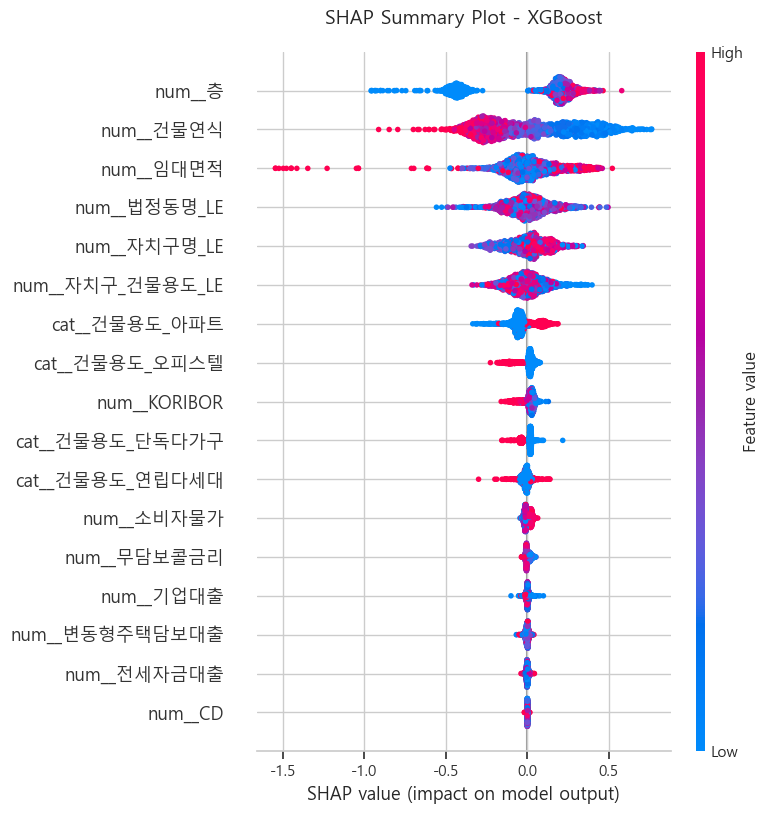

In [ ]:
# ===================================
# Summary Plot - Beeswarm (피처별 영향도)
# ===================================

plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_values, 
    X_sample_trans, 
    feature_names=feature_names, 
    show=False
)
plt.title(f"SHAP Summary Plot - {best_model}", fontsize=14, pad=20)
plt.tight_layout()
plt.show()

### SHAP Bar Plot - 평균 절대 중요도
- 평균 절대 SHAP 값으로 피처 중요도 순위 표시
- 값이 클수록 모델 예측에 더 큰 영향

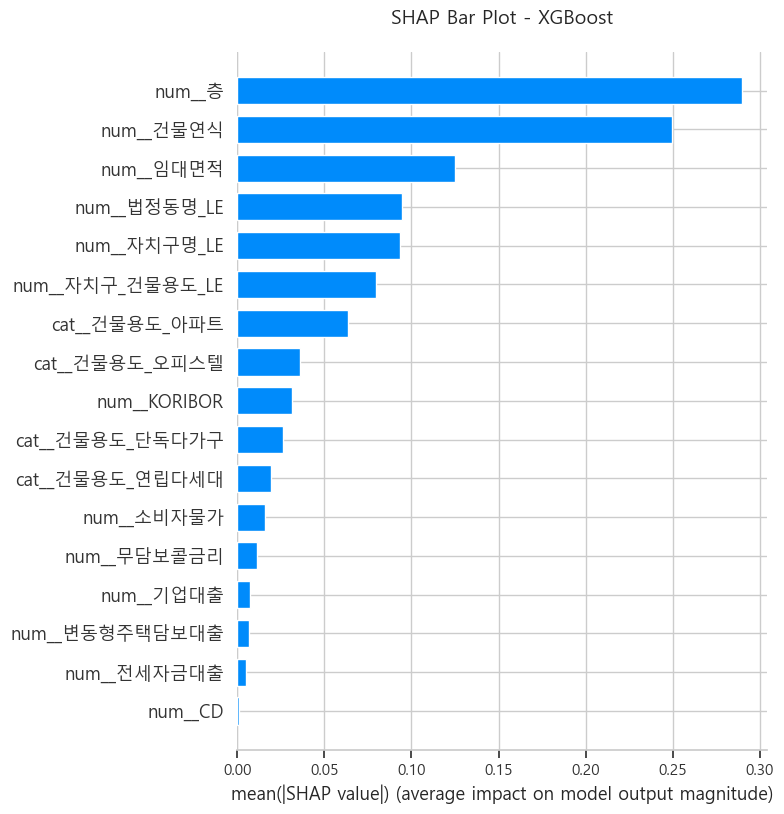

In [ ]:
# ===================================
# Bar Plot - 평균 절대 SHAP 중요도
# ===================================

plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values, 
    X_sample_trans, 
    feature_names=feature_names,
    plot_type="bar",
    show=False
)
plt.title(f"SHAP Bar Plot - {best_model}", fontsize=14, pad=20)
plt.tight_layout()
plt.show()

## 적정가 범위 시각화 (Test 데이터)
> 예측값 구간별로 오차 분포를 따로 보고, 그 구간에서의 분위수로 밴드를 잡는 방식

In [ ]:
# from sklearn.mixture import GaussianMixture
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt

# # 1) 퍼센트 잔차 데이터 (CELL 31에서 만든 error_pct 사용)
# err = error_pct.dropna().values.reshape(-1, 1)

# # 2) GMM으로 3개 구간 클러스터링
# gmm = GaussianMixture(n_components=3, random_state=42)
# gmm.fit(err)
# labels = gmm.predict(err)

# df_err = pd.DataFrame({
#     "error_pct": error_pct.dropna().values,
#     "cluster": labels
# })

# cluster_stats = (
#     df_err
#     .groupby("cluster")["error_pct"]
#     .agg(["count", "mean", "min", "max"])
#     .sort_values("mean")
# )
# print("\n[잔차 퍼센트 클러스터 통계]")
# print(cluster_stats)

# # 평균 기준으로 정렬된 클러스터: (낮은 평균, 중간, 높은 평균)
# ordered_clusters = cluster_stats.index.tolist()
# low_cluster, mid_cluster, high_cluster = ordered_clusters

# # 3) '적정' 클러스터 내부에서만 5~95% 분위수로 밴드 정의
# mid_errors = df_err.loc[df_err["cluster"] == mid_cluster, "error_pct"].values
# band_low_pct  = np.percentile(mid_errors, 5)
# band_high_pct = np.percentile(mid_errors, 95)

# print(f"\n[실제 데이터에서 나온 '적정' 밴드 범위]")
# print(f"  - 하한(5%):  {band_low_pct:.1f}%")
# print(f"  - 상한(95%): {band_high_pct:.1f}%")

# # 4) 예측 평당가에 퍼센트 밴드 적용
# band_lower = y_pred_test_real * (1 + band_low_pct / 100.0)
# band_upper = y_pred_test_real * (1 + band_high_pct / 100.0)

# # 5) 깔대기 형태 시각화 (예측 vs 실제 + 밴드)
# plt.figure(figsize=(10, 8))

# plt.scatter(y_pred_test_real, y_test_real,
#             s=10, alpha=0.4, label="실제 데이터 (Test)")
# plt.plot([y_pred_test_real.min(), y_pred_test_real.max()],
#          [y_pred_test_real.min(), y_pred_test_real.max()],
#          "k--", label="이상적 예측 (y = x)")

# idx_sort = np.argsort(y_pred_test_real)
# x_sorted = y_pred_test_real[idx_sort]
# band_lower_sorted = band_lower[idx_sort]
# band_upper_sorted = band_upper[idx_sort]

# plt.plot(x_sorted, band_lower_sorted,
#          color="orange", linewidth=2, label="적정 밴드 하단 (실제 데이터 기반)")
# plt.plot(x_sorted, band_upper_sorted,
#          color="orange", linewidth=2, label="적정 밴드 상단 (실제 데이터 기반)")

# plt.xlabel("예측 평당가 (만원)")
# plt.ylabel("실제 평당가 (만원)")
# plt.title("실제 잔차 분포 기반 TA형 깔대기 밴드 (Test)")
# plt.legend()
# plt.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.show()


In [ ]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt

# # 1) Test 예측 / 실제 / 잔차 정리
# df_band = pd.DataFrame({
#     "y_pred": y_pred_test_real,   # 예측 평당가 (만원)
#     "y_true": y_test_real,        # 실제 평당가 (만원)
# })
# df_band["resid"] = df_band["y_true"] - df_band["y_pred"]

# # 예측값 기준 정렬 (오른쪽으로 갈수록 비싼 물건)
# df_band = df_band.sort_values("y_pred").reset_index(drop=True)

# # 2) 예측값이 비슷한 구간끼리 묶어 잔차 분위수 계산 (실제 데이터 기반)
# #    - window: 각 구간에 들어갈 샘플 개수 (데이터 양에 맞게 조정, 예: 300~1000)
# window = 500

# df_band["q_low"] = (
#     df_band["resid"]
#     .rolling(window, min_periods=window // 2)
#     .quantile(0.10)      # 해당 구간 잔차의 10% 분위수
# )
# df_band["q_high"] = (
#     df_band["resid"]
#     .rolling(window, min_periods=window // 2)
#     .quantile(0.90)      # 해당 구간 잔차의 90% 분위수
# )

# # 3) 예측값 기준 밴드 (절대 가격 단위)
# df_band["band_lower"] = df_band["y_pred"] + df_band["q_low"]
# df_band["band_upper"] = df_band["y_pred"] + df_band["q_high"]

# # 부동산 가격 특성상 0 아래는 의미 없으므로 0으로 바닥 처리
# df_band["band_lower"] = df_band["band_lower"].clip(lower=0)

# # 4) 실제 Test 데이터가 밴드 안에 들어오는 비율(coverage) 확인
# valid = df_band[["y_true", "band_lower", "band_upper"]].dropna()
# coverage = ((valid["y_true"] >= valid["band_lower"]) &
#             (valid["y_true"] <= valid["band_upper"])).mean()
# print(f"밴드 안에 포함된 Test 비율(coverage): {coverage*100:.1f}%")

# # 5) 깔대기 형태 시각화
# plt.figure(figsize=(10, 8))

# # 실제 데이터 산점도
# plt.scatter(df_band["y_pred"], df_band["y_true"],
#             s=8, alpha=0.35, label="실제 데이터 (Test)")

# # 이상적 예측선 y = x
# min_val = min(df_band["y_pred"].min(), df_band["y_true"].min())
# max_val = max(df_band["y_pred"].max(), df_band["y_true"].max())
# plt.plot([min_val, max_val], [min_val, max_val],
#          "k--", label="이상적 예측 (y = x)")

# # 실제 잔차 분포로부터 나온 깔대기 밴드
# plt.plot(df_band["y_pred"], df_band["band_lower"],
#          color="orange", linewidth=2, label="밴드 하단 (잔차 10% 분위수)")
# plt.plot(df_band["y_pred"], df_band["band_upper"],
#          color="orange", linewidth=2, label="밴드 상단 (잔차 90% 분위수)")

# plt.xlabel("예측 평당가 (만원)")
# plt.ylabel("실제 평당가 (만원)")
# plt.title("예측값 구간별 실제 잔차 분포 기반 깔대기 밴드 (Test)")
# plt.legend()
# plt.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.show()
